# Point-group symmetry-enforced Wannierization

Passing `symmetries="auto"` makes `get_wannier_hamiltonian` verify, before Wannierizing, that
the selected band range is a genuine union of point-group-related multiplets everywhere on the
mesh -- rejecting a band selection that slices through a symmetry-related degeneracy instead of
silently returning a mis-symmetrized model. Kagome's famous flat band is the textbook example:
it touches the middle dispersive band exactly at the $K$ point, so no band selection containing
only the flat band is a valid symmetric choice at every k-point -- this is the well-known
topological obstruction behind why the isolated kagome flat band has no symmetric,
exponentially-localized Wannier function. The full 3-band manifold has no such obstruction and
Wannierizes cleanly with the detected point group enforced.

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

Point-group operations found: ['sigma(axis=[1.0, 0.0, 0.0])', 'C2(axis=[0.0, 1.0, 0.0])', 'sigma(axis=[0.0, 0.0, 1.0])', 'C3(axis=[0.0, 0.0, 1.0])', 'S3(axis=[0.0, 0.0, 1.0])', 'C3^2(axis=[0.0, 0.0, 1.0])', 'S3^2(axis=[0.0, 0.0, 1.0])', 'sigma(axis=[0.5, 0.866, 0.0])']



Flat band alone correctly rejected:
  get_wannier_hamiltonian: the selected band group's induced operator for symmetry C3(axis=[0.0, 0.0, 1.0]) is not unitary at k=[0.33333333 0.66666667 0.        ] (deviation 0.728) -- this band selection likely slices through a symmetry-related degenerate multiplet (picks some, not all, of it), which has no well-defined symmetry-covariant subspace for this operation; pick a band range that is a union of whole such multiplets, drop this symmetry from `symmetries`, or increase num_iter/nk if this is a convergence issue



Symmetries enforced: ['E', 'sigma(axis=[1.0, 0.0, 0.0])', 'C2(axis=[0.0, 1.0, 0.0])', 'sigma(axis=[0.0, 0.0, 1.0])', 'C3(axis=[0.0, 0.0, 1.0])', 'S3(axis=[0.0, 0.0, 1.0])', 'C3^2(axis=[0.0, 0.0, 1.0])', 'S3^2(axis=[0.0, 0.0, 1.0])', 'sigma(axis=[0.5, 0.866, 0.0])', '(sigma(axis=[1.0, 0.0, 0.0]))*(C3(axis=[0.0, 0.0, 1.0]))', '(sigma(axis=[1.0, 0.0, 0.0]))*(S3(axis=[0.0, 0.0, 1.0]))', '(sigma(axis=[1.0, 0.0, 0.0]))*(S3(axis=[0.0, 0.0, 1.0]))']
Wannier centres (Cartesian):
 [[-5.00000000e-01 -2.88675135e-01 -9.24446373e-33]
 [ 5.00000000e-01 -2.88675135e-01  1.66057960e-32]
 [-1.82145965e-17  5.77350269e-01  9.58685128e-33]]
Total spread Omega: -1.9595436384634013e-14


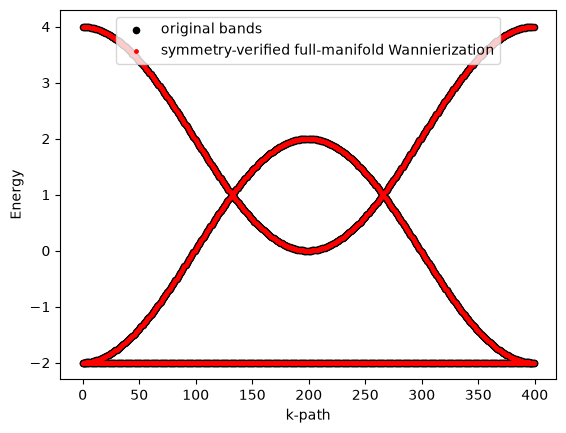

In [2]:
from pyqula.symmetrytk import pointgroup

g = geometry.kagome_lattice()
h = g.get_hamiltonian(has_spin=False)

# best-effort, dependency-free detection of the point-group operations
# actually present for this geometry+Hamiltonian
found = pointgroup.find_point_group(g, h=h)
print("Point-group operations found:", [c.op.name for c in found])

# the isolated flat band (band index 2) alone: correctly rejected
try:
    h.get_wannier_hamiltonian(bands=[2, 2], nk=12, num_iter=200, symmetries="auto")
    print("\n(unexpected: no error for the flat band alone)")
except ValueError as e:
    print("\nFlat band alone correctly rejected:\n ", str(e).splitlines()[0])

# the full 3-band manifold: trivially a union of every multiplet, Wannierizes fine
hwan_sym = h.get_wannier_hamiltonian(bands=[0, 2], nk=12, num_iter=500,
                                      symmetries="auto",
                                      trial_vectors=np.eye(3, dtype=complex))
print("\nSymmetries enforced:", [c.op.name for c in hwan_sym.wannier_symmetries])
print("Wannier centres (Cartesian):\n", hwan_sym.wannier_centres)
print("Total spread Omega:", hwan_sym.wannier_spread_total)

(k, e) = h.get_bands(write=False)
(kw, ew) = hwan_sym.get_bands(write=False)

plt.scatter(k, e, c="black", s=20, label="original bands")
plt.scatter(kw, ew, c="red", s=6, label="symmetry-verified full-manifold Wannierization")
plt.xlabel("k-path")
plt.ylabel("Energy")
plt.legend()
plt.show()